In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import pickle

In [2]:
df = pd.read_csv('/content/Customer-Churn-Records.csv')

print(df.head())
print(df.info())

   CreditScore Geography  Age  Tenure    Balance  NumOfProducts  \
0          619    France   42       2       0.00              1   
1          608     Spain   41       1   83807.86              1   
2          502    France   42       8  159660.80              3   
3          699    France   39       1       0.00              2   
4          850     Spain   43       2  125510.82              1   

   IsActiveMember  EstimatedSalary  Exited  Satisfaction Score  
0               1        101348.88       1                   2  
1               1        112542.58       0                   3  
2               0        113931.57       1                   3  
3               0         93826.63       0                   5  
4               1         79084.10       0                   5  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 

In [3]:
df = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1, errors='ignore')

# Encode categorical columns
le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

In [4]:
df['CLV'] = df['Balance'] * df['Tenure'] + df['EstimatedSalary']

In [5]:
X = df.drop(['CLV'], axis=1)
y = df['CLV']


In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)


In [7]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [8]:
model = RandomForestRegressor()
model.fit(X_train, y_train)


RandomForestRegressor()

In [9]:
y_pred = model.predict(X_test)


In [10]:
print("MAE:", mean_absolute_error(y_test, y_pred))

print("R2 Score:", r2_score(y_test, y_pred))


MAE: 6050.009455799996
R2 Score: 0.9990963785712751


In [11]:
pickle.dump(model, open('clv_model.pkl', 'wb'))
pickle.dump(scaler, open('scaler.pkl', 'wb'))


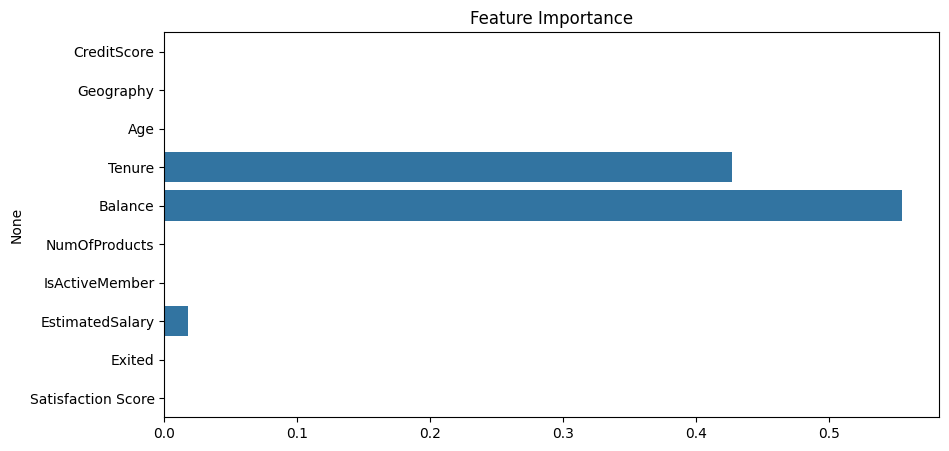

In [12]:
importances = model.feature_importances_
feat_names = X.columns

plt.figure(figsize=(10,5))
sns.barplot(x=importances, y=feat_names)
plt.title("Feature Importance")
plt.show()


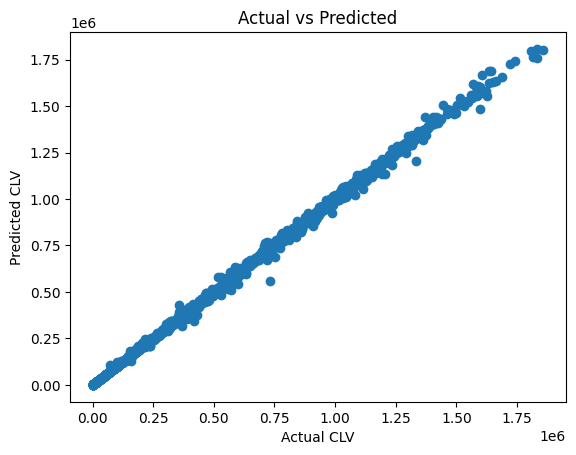

In [13]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual CLV")
plt.ylabel("Predicted CLV")
plt.title("Actual vs Predicted")
plt.show()